<a href="https://colab.research.google.com/github/bhimappa-123/Bhima/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torchvision import datasets, transforms

In [ ]:
dataset = datasets.MNIST(root='./data', train=True, download=True,
                         transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.18MB/s]


In [ ]:
x_train = dataset.data
y_train = dataset.targets

In [ ]:
selected_classes = [0, 1, 2]

In [ ]:
for cls in selected_classes:
    indices = (y_train == cls).nonzero(as_tuple=True)[0][:100]
    print(indices)


tensor([   1,   21,   34,   37,   51,   56,   63,   68,   69,   75,   81,   88,
          95,  108,  114,  118,  119,  121,  156,  169,  192,  206,  209,  210,
         216,  229,  232,  234,  246,  249,  260,  283,  293,  296,  303,  320,
         326,  359,  399,  427,  429,  435,  440,  451,  453,  458,  462,  464,
         473,  489,  519,  524,  526,  527,  542,  577,  582,  596,  603,  612,
         633,  639,  656,  662,  666,  667,  668,  669,  689,  702,  709,  712,
         733,  743,  745,  776,  781,  787,  790,  818,  825,  849,  859,  860,
         869,  872,  889,  903,  927,  943,  949,  952,  957,  965,  979,  984,
         997, 1000, 1015, 1018])
tensor([  3,   6,   8,  14,  23,  24,  40,  59,  67,  70,  72,  77,  78,  99,
        102, 104, 105, 112, 113, 124, 128, 134, 152, 174, 177, 184, 200, 201,
        205, 208, 211, 224, 231, 248, 251, 269, 270, 276, 290, 309, 310, 315,
        345, 351, 355, 357, 358, 366, 382, 394, 397, 398, 406, 408, 416, 443,
        447, 45

In [ ]:
x_final, y_final = [], []
for cls in selected_classes:
    indices = (y_train == cls).nonzero(as_tuple=True)[0][:100]
    x_final.append(x_train[indices])
    y_final.append(y_train[indices])

In [ ]:
len(x_final)

3

In [ ]:
xx = torch.cat(x_final)
yy = torch.cat(y_final)

In [ ]:
yy

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
xx = xx.view(xx.size(0), -1).float()
yy = yy.long()

In [ ]:
dataset = TensorDataset(xx, yy)
data = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
import torch.nn as nn

class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(32 * 14 * 14, 64)
        self.fc2 = nn.Linear(64, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [ ]:
model = MyModel()

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
model.train()
epochs = 50

for epoch in range(epochs):

    for batch_x, batch_y in data:

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.0
Epoch 2, Loss: 0.0
Epoch 3, Loss: 0.0
Epoch 4, Loss: 0.0
Epoch 5, Loss: 9.934106870446158e-09
Epoch 6, Loss: 5.463741103994835e-07
Epoch 7, Loss: 0.0
Epoch 8, Loss: 0.0
Epoch 9, Loss: 5.850983598065795e-06
Epoch 10, Loss: 0.0
Epoch 11, Loss: 0.0
Epoch 12, Loss: 5.265060281089973e-07
Epoch 13, Loss: 0.0
Epoch 14, Loss: 0.0
Epoch 15, Loss: 0.0
Epoch 16, Loss: 0.0
Epoch 17, Loss: 0.0
Epoch 18, Loss: 0.0
Epoch 19, Loss: 0.0
Epoch 20, Loss: 0.0
Epoch 21, Loss: 1.2417541483955574e-06
Epoch 22, Loss: 0.0
Epoch 23, Loss: 0.0
Epoch 24, Loss: 1.9868211964535476e-08
Epoch 25, Loss: 0.0
Epoch 26, Loss: 0.0
Epoch 27, Loss: 0.0
Epoch 28, Loss: 2.9802317058624794e-08
Epoch 29, Loss: 0.0
Epoch 30, Loss: 1.9868211964535476e-08
Epoch 31, Loss: 1.1821509815490572e-06
Epoch 32, Loss: 0.0
Epoch 33, Loss: 0.0
Epoch 34, Loss: 0.0
Epoch 35, Loss: 5.861102749804559e-07
Epoch 36, Loss: 4.669017243941198e-07
Epoch 37, Loss: 1.6788548009571969e-06
Epoch 38, Loss: 0.0
Epoch 39, Loss: 0.0
Epoch 4

In [ ]:
model.eval()

sample = xx[0].unsqueeze(0)

with torch.no_grad():
    output = model(sample)
    _, predicted = torch.max(output, 1)

print("Prediction:", predicted.item())

Prediction: 0


In [ ]:
print("Predicted:", predicted.item())
print("Actual:", yy[0].item())

Predicted: 0
Actual: 0


In [ ]:
torch.save(model.state_dict(), 'model_weights.pth')

TransferLearning

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam, SGD

In [ ]:
from torchvision import models, transforms, datasets

In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

In [ ]:
train_dataset.data[0].shape

torch.Size([28, 28])

In [ ]:
import matplotlib.pyplot as plt

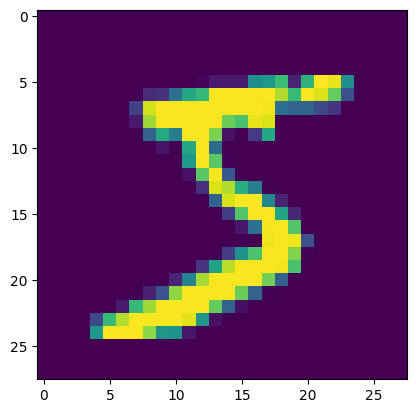

In [ ]:
plt.imshow(train_dataset.data[0])

In [ ]:
img = train_dataset.data

In [ ]:
lbs = train_dataset.targets

In [ ]:
img = img[:100]
lbs = lbs[:100]
import cv2
import numpy as np

In [ ]:
ls = []
for k in range(100):
    img_np = img[k].numpy()
    color = cv2.cvtColor(np.float32(img_np), cv2.COLOR_GRAY2RGB)
    rsz = cv2.resize(color, (224,224))
    ls.append(rsz)

In [ ]:
ar = np.array(ls)
ar.shape

(100, 224, 224, 3)

In [ ]:
X = ar.reshape(100,3,224,224)
X.shape

(100, 3, 224, 224)

In [ ]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(lbs)
Y.shape

torch.Size([100])

In [ ]:
mod = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.4MB/s]


In [ ]:
for k in mod.parameters():
  print(k.shape)

torch.Size([64, 3, 3, 3])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([128, 64, 3, 3])
torch.Size([128])
torch.Size([128, 128, 3, 3])
torch.Size([128])
torch.Size([256, 128, 3, 3])
torch.Size([256])
torch.Size([256, 256, 3, 3])
torch.Size([256])
torch.Size([256, 256, 3, 3])
torch.Size([256])
torch.Size([512, 256, 3, 3])
torch.Size([512])
torch.Size([512, 512, 3, 3])
torch.Size([512])
torch.Size([512, 512, 3, 3])
torch.Size([512])
torch.Size([512, 512, 3, 3])
torch.Size([512])
torch.Size([512, 512, 3, 3])
torch.Size([512])
torch.Size([512, 512, 3, 3])
torch.Size([512])
torch.Size([4096, 25088])
torch.Size([4096])
torch.Size([4096, 4096])
torch.Size([4096])
torch.Size([1000, 4096])
torch.Size([1000])


In [ ]:
for param in mod.parameters():
    param.requires_grad = False

for p in mod.classifier[6].parameters():
  p.requires_grad = True

for param in mod.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True


In [ ]:
opt = Adam(mod.parameters(), lr=0.001)
lossfn = nn.CrossEntropyLoss()

In [ ]:
transfer_dataset = TensorDataset(X, Y)
transfer_data_loader = DataLoader(transfer_dataset, batch_size=32, shuffle=True)

for epoch in range(3):

    total_loss = 0

    for batch_x, batch_y in transfer_data_loader:

        pred = mod(batch_x)
        loss = lossfn(pred, batch_y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(transfer_data_loader)}")

Epoch 1, Loss: 8.405705332756042
Epoch 2, Loss: 8.003666877746582
Epoch 3, Loss: 8.979483604431152


In [ ]:
X[0].shape

torch.Size([3, 224, 224])

In [ ]:
test = X[0].reshape(1, 3, 224, 224)

In [ ]:
sfx = torch.softmax(mod(test), dim=1)

In [ ]:
torch.argmax(sfx, dim=1)

tensor([1])

TransferLearning(Gradio)

In [2]:
import zipfile
import os

zip_file_path = "/content/animals.zip"

extract_dir = "."

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.path.abspath(extract_dir))

/content


In [3]:
from pathlib import Path

In [4]:
p = Path("/content/animals")

In [5]:
images = []
for f in p.rglob('*'):
  if '.png' in str(f) or '.jpg' in str(f):
    print(f)
    images.append(f)

/content/animals/catthree.png
/content/animals/cattwo.png
/content/animals/catfour.png
/content/animals/rat4.png
/content/animals/rat3.png
/content/animals/rat1.png
/content/animals/catfive.png
/content/animals/dogone.png
/content/animals/dog5.png
/content/animals/dog2.png
/content/animals/cat.png
/content/animals/rat5.png
/content/animals/dog4.png
/content/animals/rat2.png
/content/animals/dog3.png


In [11]:
st = "/content/animals/dog5.png"

In [13]:
Y = []
for st in images:
  if 'rat' in str(st):
    Y.append(0)
  elif 'dog' in str(st):
    Y.append(1)
  else:
    Y.append(2)

In [14]:
Y

[2, 2, 2, 0, 0, 0, 2, 1, 1, 1, 2, 0, 1, 0, 1]

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

In [16]:
class AnimalDataset(Dataset):
    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)

        label = torch.tensor(self.labels[idx])

        return img, label

In [17]:
dataset = AnimalDataset(images, Y)

In [23]:
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [24]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [25]:
model = CNN()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [26]:
for epoch in range(5):
    for X_batch, Y_batch in loader:

        pred = model(X_batch)
        loss = loss_fn(pred, Y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.0990606546401978
Epoch: 1 Loss: 1.9811286926269531
Epoch: 2 Loss: 5.074340343475342
Epoch: 3 Loss: 2.19842529296875
Epoch: 4 Loss: 2.3054358959198


In [27]:
from torchvision import models

model = models.vgg16(pretrained=True)

model.classifier[6] = nn.Linear(4096, 3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.0MB/s]


In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

In [29]:
for param in model.parameters():
    param.requires_grad = False

In [30]:
for param in model.classifier[6].parameters():
    param.requires_grad = True

In [31]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.classifier[6].parameters(), lr=0.001)

In [32]:
for epoch in range(5):

    model.train()

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        pred = model(X_batch)
        loss = loss_fn(pred, Y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.2997281551361084
Epoch: 1 Loss: 0.768002450466156
Epoch: 2 Loss: 0.5977855324745178
Epoch: 3 Loss: 0.28630149364471436
Epoch: 4 Loss: 0.21521086990833282


In [33]:
import torch
from torch.utils.data import random_split, DataLoader

model.eval()

correct = 0
total = 0


train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

with torch.no_grad():
    for X_batch, Y_batch in val_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        pred = model(X_batch)
        _, predicted = torch.max(pred, 1)

        correct += (predicted == Y_batch).sum().item()
        total += Y_batch.size(0)

print("Accuracy:", correct / total)

Accuracy: 1.0


In [34]:
def predict_image(path):
    from PIL import Image
    import torchvision.transforms as transforms

    classes = ['rat', 'dog', 'other']

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    return classes[pred.item()]

In [35]:
print(predict_image("/content/animals/rat3.png"))
print(predict_image("/content/animals/dog4.png"))

rat
dog


In [36]:
import torch.nn.functional as F

def predict_image(path):
    from PIL import Image
    import torchvision.transforms as transforms

    classes = ['rat', 'dog', 'other']

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(img)
        probs = F.softmax(output, dim=1)
        confidence, pred = torch.max(probs, 1)

    return classes[pred.item()], confidence.item()

In [37]:
label, conf = predict_image("/content/animals/dog4.png")

print("Prediction:", label)
print("Confidence:", conf)

Prediction: dog
Confidence: 0.8834770321846008


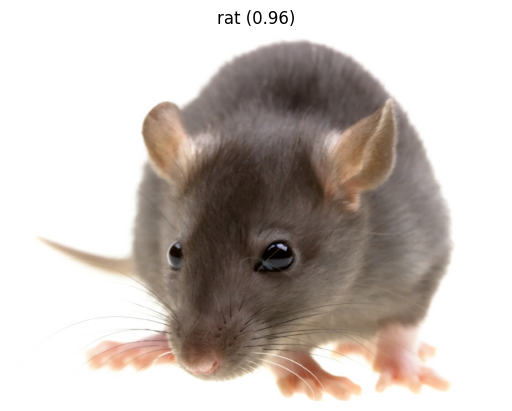

In [38]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/content/animals/rat3.png"

label, conf = predict_image(img_path)

img = Image.open(img_path)

plt.imshow(img)
plt.title(f"{label} ({conf:.2f})")
plt.axis('off')
plt.show()

In [39]:
torch.save(model.state_dict(), "animal_model.pth")

In [40]:
model.load_state_dict(torch.load("animal_model.pth"))
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

GradioApp

In [ ]:
#!pip install gradio

In [41]:
torch.save(model.state_dict(), "animal_model.pth")

In [42]:
import torch
import torch.nn as nn
from torchvision import models

device = 'cuda' if torch.cuda.is_available() else 'cpu'


model = models.vgg16(pretrained=True)
model.classifier[6] = nn.Linear(4096, 3)

model.load_state_dict(torch.load("animal_model.pth", map_location=device))
model.eval()
model = model.to(device)

In [43]:
from PIL import Image
import torchvision.transforms as transforms
import torch.nn.functional as F

classes = ['rat', 'dog', 'cat']

def predict(img):
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    img = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = model(img)
        probs = F.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

    return f"{classes[pred.item()]} (Confidence: {conf.item():.2f})"

In [44]:
import gradio as gr

interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Animal Classifier 🐾",
    description="Upload image → get prediction"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f81d580a6a2512b55e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
